
# Lab 9: Quantun Computing - Rabi Oscillations

Nombre estudiante:

c.c:

## Exercise 1: $NH_3$ molecule

An example of the quantum oscillations in two-level systems may be rather unexpected; for example, the ammonium molecule 

![NH3](../Sesiones/QC/figures/NH3.png)
![NH3](NH3.png)

 It has two symmetric states that differ by the inversion of the nitrogen atom relative to the plane of the three hydrogen atoms, which are weakly coupled due to quantum-mechanical tunneling of the nitrogen atom through the plane of the hydrogen atoms. Since for this particular molecule, in the absence of external fields, the level splitting $\Delta E$ corresponds to an experimentally convenient frequency $\Omega/2\pi\approx$ 24.79 GHz.

 1. Supose a detuning frequency $\Omega_R/2$.
 2. Compute the Rabi frequency for NH3 molecule in Hz and do a plot of the Rabi oscillation. Supose that the initial state is $\ket{2}$.
 
 [see](https://phys.libretexts.org/Bookshelves/Quantum_Mechanics/Essential_Graduate_Physics_-_Quantum_Mechanics_(Likharev)/05%3A_Some_Exactly_Solvable_Problems/5.01%3A_Two-level_Systems)

## Solución a Ejercicio 1:



In [2]:
# Librerias: 

import numpy as np
import matplotlib.pyplot as plt

Omega     = 1.558e+11 rad/s
Omega_R   = 1.393e+11 rad/s
Delta     = 6.966e+10 rad/s
f_R       = 22.17 GHz


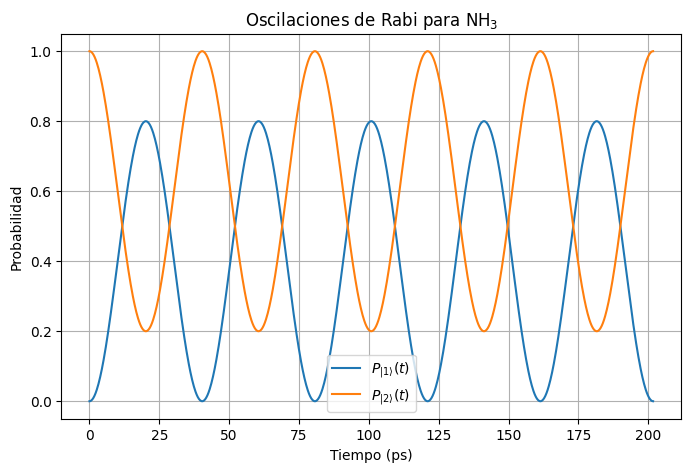

In [ ]:

# Datos del NH3
f = 24.79e9                 # Hz
Omega = 2*np.pi*f           # rad/s

# Detuning: Delta = Omega_R/2
Omega_R = (2/np.sqrt(5))*Omega
Delta = Omega_R/2

print(f"Omega     = {Omega:.3e} rad/s")
print(f"Omega_R   = {Omega_R:.3e} rad/s")
print(f"Delta     = {Delta:.3e} rad/s")
print(f"f_R       = {Omega_R/(2*np.pi)/1e9:.2f} GHz")

# Intervalo temporal
T = 2*np.pi/Omega           # periodo de oscilación

t = np.linspace(0, 5*T, 1000)

# Probabilidades
P1 = (Omega_R**2/Omega**2) * np.sin(Omega*t/2)**2
P2 = 1 - P1

# Gráfica
plt.figure(figsize=(8,5))
plt.plot(t*1e12, P1, label=r'$P_{|1\rangle}(t)$')
plt.plot(t*1e12, P2, label=r'$P_{|2\rangle}(t)$')
plt.xlabel('Tiempo (ps)')
plt.ylabel('Probabilidad')
plt.title('Oscilaciones de Rabi para NH$_3$')
plt.grid(True)
plt.legend()

plt.show()

# 2. Encontrando las Frecuencias de Rabbi:

Tomando el código visto y estudiado en clase, tenemos:

In [4]:
hbar = 1.0545718e-34 # Planck's constant over 2 pi in J*s
#Rabi frequency:
def Omega_Rabi(cx,cy):
    return np.sqrt(cx**2 + cy**2)/hbar
#Detuning:
def Delta(cz):
    return np.abs(cz)/hbar
#Generalized Rabi frequency:
def Omega(cx,cy,cz):
    return np.sqrt(Omega_Rabi(cx,cy)**2 + Delta(cz)**2)
#Probability of being in state |1> at time t:
def P1(cx,cy,cz,t):
    return np.cos(Omega(cx,cy,cz)*t)**2 + np.sin(Omega(cx,cy,cz)*t)**2*(Delta(cz)/Omega(cx,cy,cz))**2

Rabi frequency: 1.349e+11 Hz
Detuning: 7.790e+10 Hz
Generalized Rabi frequency: 1.558e+11 Hz


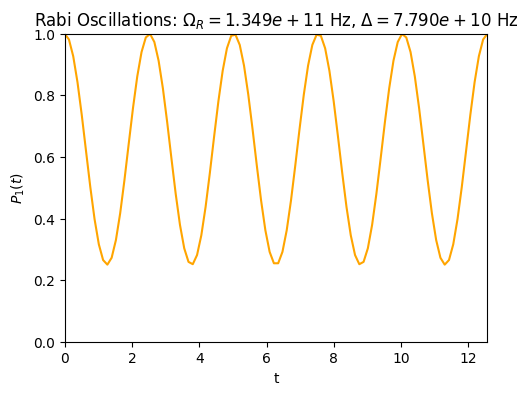

In [7]:
# Graficando bajo los parámetros anteriores:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 2)
# Benchmark parameters
omega0 = 1.558e+11
cx = np.sqrt(3/4)*omega0*hbar/np.sqrt(2)
cy = cx
#cz = np.sqrt(omega0*2-Omega_Rabi(cx,cy)**2)*hbar
cz = omega0*hbar/2

print(f"Rabi frequency: {Omega_Rabi(cx,cy):.3e} Hz")
print(f"Detuning: {Delta(cz):.3e} Hz")
print(f"Generalized Rabi frequency: {Omega(cx,cy,cz):.3e} Hz")

t = np.linspace(0, 4*np.pi, 100)
Pr = P1(cx,cy,cz,t)
plt.plot(t, Pr, color='orange', label='P1 with cx=1, cy=0, cz=0')
plt.xlabel('t')
plt.ylabel('$P_1(t)$')
plt.xlim(t.min(), t.max())
plt.ylim(0, 1)
plt.title(f'Rabi Oscillations: $\\Omega_R={Omega_Rabi(cx,cy):.3e}$ Hz, $\\Delta={Delta(cz):.3e}$ Hz')
plt.show()

Podríamos afirmar qué la forma de la curva tiene sentido:

* Empieza en $P_2(0)=1$ porque el estado inicial es $|2\rangle$.
* La probabilidad oscila periódicamente.
* Debido al detuning $(\Delta\neq 0)$, la transición no es completa.
* El mínimo es aproximadamente $0.25$, lo cual coincide con

${P_2(t)=1-\frac{\Omega_R^2}{\Omega^2}\sin^2\left(\frac{\Omega t}{2}\right)}$

y usando los valores de la gráfica:

$\frac{\Omega_R^2}{\Omega^2} = \left(\frac{1.349\times10^{11}}{1.558\times10^{11}}\right)^2
\approx 0.75.$

Por tanto,

$P_{2,\min}=1-0.75=0.25$,

exactamente lo que se observa.

Nota: 3.5 falto el segundo... muy bien por acercarse a estos temas. 